## Setup and Imports

In [1]:
import os

# Configure JAX for CPU computation
os.environ["JAX_PLATFORM_NAME"] = "cpu"

# Standard library imports
from functools import partial

# JAX ecosystem importspip
import jax
import jax.numpy as jnp
import jax_cosmo as jc

# Scientific computing imports
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Differential equation solver
from diffrax import ODETerm, SaveAt, diffeqsolve, SemiImplicitEuler, ConstantStepSize

# JaxPM imports
from jaxpm.pm import linear_field, lpt
from jaxpm.ode import symplectic_ode
from jaxpm.lensing import spherical_density_fn, convergence_Born
from jaxpm.kernels import interpolate_power_spectrum

# Cosmology imports
from cosmology.compat.camb import Cosmology

# Glass and CAMB imports
import glass
import camb

# Configure JAX
jax.config.update("jax_enable_x64", True)

print(f"✓ JAX backend: {jax.default_backend()}")
print(f"✓ All imports successful!")

/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
ERROR:2025-11-17 19:39:51,712:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cud

✓ JAX backend: cpu
✓ All imports successful!


## Configuration Parameters

In [2]:
# =============================================================================
# CONFIGURATION PARAMETERS
# =============================================================================

# Simulation parameters
mesh_size = 256  # Mesh resolution (256³)
z_sources = [0.3, 0.5, 0.8]  # Source redshifts for convergence calculation (multi-redshift)
nside = 256      # HEALPix resolution
n_shells = 40    # Number of spherical shells
seed = 42        # Random seed for reproducibility

# Time evolution parameters
t0, t1 = 0.1, 1.0  # Scale factor range
dt0 = 0.05         # Initial timestep

# Observer configuration
observer_position_in_box = jnp.array([0.5, 0.5, 0.5])  # Centered observer in unit box

# Analysis parameters
low_ell_cutoff = 2  # Low-ell cutoff for power spectrum analysis

# Display configuration
print("✓ Configuration Parameters:")
print(f"  Mesh size: {mesh_size}³")
print(f"  Source redshifts: {z_sources}")
print(f"  HEALPix nside: {nside} (npix = {hp.nside2npix(nside):,})")
print(f"  Number of shells: {n_shells}")
print(f"  Time range: a = [{t0}, {t1}]")
print(f"  Random seed: {seed}")
print(f"  Low-ell cutoff: {low_ell_cutoff}")

✓ Configuration Parameters:
  Mesh size: 256³
  Source redshifts: [0.3, 0.5, 0.8]
  HEALPix nside: 256 (npix = 786,432)
  Number of shells: 40
  Time range: a = [0.1, 1.0]
  Random seed: 42
  Low-ell cutoff: 2


## Simulation Setup

In [3]:
# =============================================================================
# SIMULATION SETUP
# =============================================================================

# Define Planck 2018 cosmology
Planck18 = partial(
    jc.Cosmology,
    Omega_c=0.2607,
    Omega_b=0.0490,
    Omega_k=0.0,
    h=0.6766,
    n_s=0.9665,
    sigma8=0.8102,
    w0=-1.0,
    wa=0.0,
)

cosmo = Planck18()

print("✓ Cosmology Setup:")
print(f"  H0 = {cosmo.h * 100:.1f} km/s/Mpc")
print(f"  Ωm = {cosmo.Omega_c + cosmo.Omega_b:.4f}")
print(f"  Ωc = {cosmo.Omega_c:.4f}")
print(f"  Ωb = {cosmo.Omega_b:.4f}")
print(f"  σ8 = {cosmo.sigma8:.4f}")
print(f"  n_s = {cosmo.n_s:.4f}")

✓ Cosmology Setup:
  H0 = 67.7 km/s/Mpc
  Ωm = 0.3097
  Ωc = 0.2607
  Ωb = 0.0490
  σ8 = 0.8102
  n_s = 0.9665


## JaxPM Density Maps

In [4]:
# Compute simulation geometry
z_max = max(z_sources)
r_comoving = jc.background.radial_comoving_distance(cosmo, jc.utils.z2a(z_max)).squeeze()

factors = jnp.clip(jnp.array(observer_position_in_box), 0.0, 0.5)
factors = 1.0 + 2.0 * jnp.minimum(factors, 1.0 - factors)

# Box size: twice the comoving distance (observer at center)
box_size = tuple(map(float, factors * r_comoving))  # (Lx, Ly, Lz) in Mpc/h
observer_position = jnp.array(observer_position_in_box) * jnp.array(box_size)
d_R = (r_comoving / n_shells).squeeze()  # Shell thickness in Mpc/h
mesh_shape = (mesh_size, mesh_size, mesh_size)

print("✓ Simulation Geometry:")
print(f"  Comoving distance to z={z_max}: {r_comoving:.1f} Mpc/h")
print(f"  Box size: {box_size} Mpc/h ")
print(f"  Observer position in the box : {observer_position_in_box}")
print(f"  Volume: {(box_size[0] / 1000) ** 3:.2f} (Gpc/h)³")
print(f"  Shell thickness: {d_R:.1f} Mpc/h")
print(f"  Mesh shape: {mesh_shape}")
print(f"  Number of source redshifts: {len(z_sources)}")

✓ Simulation Geometry:
  Comoving distance to z=0.8: 1942.1 Mpc/h
  Box size: (3884.2124496171973, 3884.2124496171973, 3884.2124496171973) Mpc/h 
  Observer position in the box : [0.5 0.5 0.5]
  Volume: 58.60 (Gpc/h)³
  Shell thickness: 48.6 Mpc/h
  Mesh shape: (256, 256, 256)
  Number of source redshifts: 3


## JaxPM Simulation: Generate Density Planes

In [5]:
def run_jaxpm_simulation(mesh_shape, box_size, observer_position, nside, r_comoving, 
                        t0, t1, dt0, seed, cosmo, n_shells):
    """
    Run JaxPM N-body simulation and extract spherical density planes.
    
    Note: This generates density planes that can be used for multiple source redshifts.
    The density planes are independent of the specific source redshift values.
    """
    print("=" * 60)
    print("JaxPM N-body Simulation")
    print("=" * 60)
    
    # 1. Create initial conditions
    print("1. Generating initial conditions...")
    k = jnp.logspace(-3, 1, 256)
    pk = jc.power.linear_matter_power(cosmo, k)
    cosmo._workspace = {}
    
    pk_fn = lambda x: interpolate_power_spectrum(x, k, pk, sharding=None)

    initial_conditions = linear_field(
        mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(seed), sharding=None
    )
    print(
        f"   δ statistics: mean={float(jnp.mean(initial_conditions)):.2e}, "
        f"std={float(jnp.std(initial_conditions)):.3f}"
    )

    # 2. LPT displacements
    print("2. Computing LPT displacements...")
    dx, p, f = lpt(cosmo, initial_conditions, particles=None, a=t0, order=1,
                   sharding=None, halo_size=0)
    cosmo._workspace = {}

    # 3. Setup time evolution
    print("3. Setting up time evolution...")
    drift, kick = symplectic_ode(mesh_shape, paint_absolute_pos=False, 
                                halo_size=0, sharding=None)
    ode_fn = ODETerm(kick), ODETerm(drift)
    
    solver = SemiImplicitEuler()

    # 4. Define spherical shells
    print("4. Defining spherical shells...")
    d_R = (r_comoving / n_shells).squeeze()  # Shell thickness in M
    r = jnp.linspace(0.0, r_comoving, n_shells)
    r_center = 0.5 * (r[1:] + r[:-1])
    a_center = jc.background.a_of_chi(cosmo, r_center)
    cosmo._workspace = {}
    print(
        f"   Redshift range: z = {float(1 / jnp.max(a_center) - 1):.3f} - "
        f"{float(1 / jnp.min(a_center) - 1):.3f}"
    )
    time_steps = a_center[::-1]  # Reverse order for time evolution

    saveat = SaveAt(
        ts=time_steps,
        fn=lambda t, y, args: spherical_density_fn(
            mesh_shape, box_size, nside, observer_position, d_R, sharding=None
        )(t, y[1], args),
    )

    # 5. Run simulation
    print("5. Running N-body simulation...")
    y0 = (p, dx)
    
    res = diffeqsolve(
        ode_fn,
        solver,
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0,
        args=cosmo,
        saveat=saveat,
        stepsize_controller=ConstantStepSize(),
    )

    density_planes = res.ys
    print(f"   Simulation completed: {len(density_planes)} density planes")
    
    # Return density planes and shell information
    return density_planes, r_center, a_center
# Run JaxPM simulation (same as before - density planes work for any source redshift)
density_planes_jaxpm, r_center, a_center = run_jaxpm_simulation(
    mesh_shape, box_size, observer_position, nside, r_comoving, 
    t0, t1, dt0, seed, cosmo, n_shells
)

print(f"\n✓ JaxPM simulation completed!")
print(f"  Density planes shape: {density_planes_jaxpm.shape}")
print(f"  Shell centers: {len(r_center)} shells")
print(f"  Scale factors: {len(a_center)} values")

JaxPM N-body Simulation
1. Generating initial conditions...
   δ statistics: mean=-1.89e-04, std=0.843
2. Computing LPT displacements...
shape of initial force: (256, 256, 256, 3)
growth factor shape: (1,)
3. Setting up time evolution...
4. Defining spherical shells...
   Redshift range: z = 0.008 - 0.787
5. Running N-body simulation...


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


   Simulation completed: 39 density planes

✓ JaxPM simulation completed!
  Density planes shape: (39, 786432)
  Shell centers: 39 shells
  Scale factors: 39 values


## JaxPM: Compute Born Convergence

In [6]:
print("Computing JaxPM Born convergence for multiple redshifts...")

# Reverse time ordering for convergence calculation
lightcone = density_planes_jaxpm[::-1]

# Compute convergence using JaxPM's Born approximation for multiple source redshifts
# The convergence_Born function supports multiple redshifts natively
convergence_jaxpm_multi = convergence_Born(
    cosmo, lightcone, r_center, a_center, jnp.array(z_sources), d_R
)

print(f"✓ JaxPM multi-redshift convergence computed:")
print(f"  Shape: {convergence_jaxpm_multi.shape}")
print(f"  Expected shape: ({len(z_sources)}, {hp.nside2npix(nside)})")

# Print statistics for each redshift
for i, z in enumerate(z_sources):
    convergence_z = convergence_jaxpm_multi[i]
    print(f"  z = {z:.1f}: Mean = {float(jnp.mean(convergence_z)):.2e}, "
          f"Std = {float(jnp.std(convergence_z)):.2e}, "
          f"RMS = {float(jnp.sqrt(jnp.mean(convergence_z**2))):.6f}")

print(f"\n✓ All {len(z_sources)} redshift convergence maps computed successfully!")

Computing JaxPM Born convergence for multiple redshifts...
✓ JaxPM multi-redshift convergence computed:
  Shape: (3, 786432)
  Expected shape: (3, 786432)
  z = 0.3: Mean = 4.17e-19, Std = 7.64e-03, RMS = 0.007635
  z = 0.5: Mean = 1.11e-18, Std = 9.93e-03, RMS = 0.009929
  z = 0.8: Mean = 1.82e-18, Std = 1.25e-02, RMS = 0.012512

✓ All 3 redshift convergence maps computed successfully!


In [7]:
from jaxpm.spherical import spherical_visibility_mask

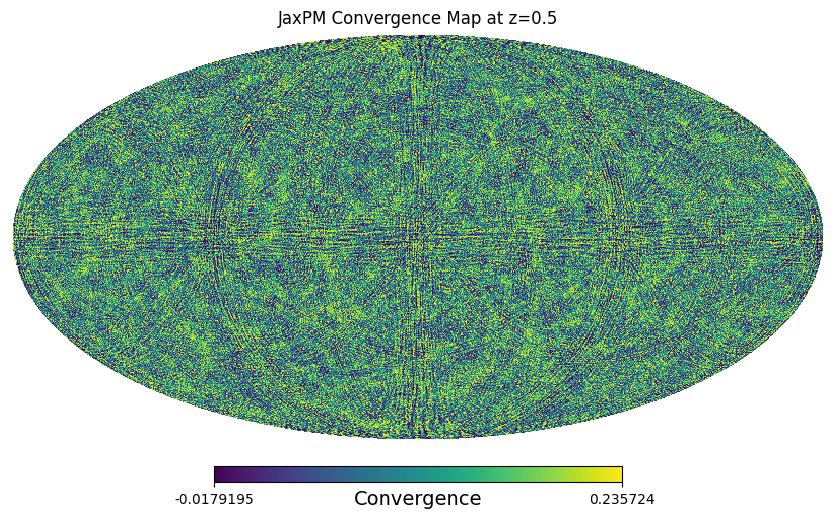

In [8]:

hp.mollview(convergence_jaxpm_multi[1], title=f"JaxPM Convergence Map at z={z_sources[1]}", unit="Convergence", norm='hist')
plt.show()

## Glass Simulation: Same Density Planes

In [9]:
print("=" * 80)
print("GLASS PREPARATION")
print("=" * 80)

# Convert JaxPM density planes to Glass format
print("1. Converting density planes to Glass format...")

# Glass expects overdensity δ = ρ/ρ̄ - 1
density_planes_glass = []
plane_stats = []
for i, plane in enumerate(lightcone):
    # Convert to numpy and compute overdensity
    plane_np = np.array(plane)
    mean_density = np.mean(plane_np)
    if mean_density > 0:
        delta = plane_np / mean_density - 1.0
    else:
        delta = np.zeros_like(plane_np)
    
    density_planes_glass.append(delta)
    plane_stats.append((float(np.mean(delta)), float(np.std(delta))))

# GLASS expects shells ordered from near to far; solver outputs far to near
plane_stats = plane_stats[::-1]

print(f"   Converted {len(density_planes_glass)} planes")
print("   Reordered density planes (near to far)")
for i, (delta_mean, delta_std) in enumerate(plane_stats[:3]):
    print(f"   Plane {i}: mean_δ = {delta_mean:.6f}, std_δ = {delta_std:.6f}")

# Setup Glass cosmology to exactly match our jax_cosmo parameters
print("2. Setting up Glass cosmology...")

# Extract cosmology parameters from jax_cosmo
h = cosmo.h
omega_m = cosmo.Omega_c + cosmo.Omega_b
Oc = cosmo.Omega_c  # CDM density
Ob = cosmo.Omega_b  # Baryon density

# Create CAMB parameters matching our cosmology exactly
pars = camb.set_params(
    H0=100 * h,
    omch2=Oc * h**2,
    ombh2=Ob * h**2,
    NonLinear=camb.model.NonLinear_both,
)
results = camb.get_background(pars)

# Create Glass cosmology object from CAMB parameters
glass_cosmo = Cosmology(results)
print(f"   Glass cosmology created: h={h:.3f}, Ωm={omega_m:.4f}")
print(f"   Parameter verification: H0={pars.H0:.1f}, Ωch²={pars.omch2:.4f}, Ωbh²={pars.ombh2:.4f}")

GLASS PREPARATION
1. Converting density planes to Glass format...
   Converted 39 planes
   Reordered density planes (near to far)
   Plane 0: mean_δ = -0.000000, std_δ = 0.468733
   Plane 1: mean_δ = 0.000000, std_δ = 0.487005
   Plane 2: mean_δ = -0.000000, std_δ = 0.504621
2. Setting up Glass cosmology...
   Glass cosmology created: h=0.677, Ωm=0.3097
   Parameter verification: H0=67.7, Ωch²=0.1193, Ωbh²=0.0224


In [10]:
print("=" * 60)
print("Glass Top-Hat Window Convergence")
print("=" * 60)

# 1. Define the shell edges in redshift
r_edges = jnp.linspace(0.0, box_size[-1]-observer_position[-1], len(r_center)+1)
z_edges = np.array(jc.utils.a2z(jc.background.a_of_chi(cosmo, r_edges)))
shells_tophat = glass.tophat_windows(z_edges)   # -> 39 windows

print(f"   Created {len(shells_tophat)} top-hat windows")

print("Computing Glass top-hat convergence…")

z_targets = np.array(z_sources, dtype=float)
sort_idx = np.argsort(z_targets)
sorted_targets = z_targets[sort_idx]
stored_maps = {}
target_ptr = 0

convergence_glass_top_hat_calc = glass.MultiPlaneConvergence(glass_cosmo)
prev_kappa = None
prev_zeff = None
tol = 5e-3

for i, (delta_i, win) in enumerate(zip(density_planes_glass, shells_tophat)):
    convergence_glass_top_hat_calc.add_window(delta_i, win)
    current_kappa = np.array(convergence_glass_top_hat_calc.kappa, copy=True)
    current_zeff = win.zeff
    
    if prev_kappa is None:
        prev_kappa = np.zeros_like(current_kappa)
    if prev_zeff is None:
        prev_zeff = 0.0
    
    while target_ptr < len(sorted_targets) and current_zeff + tol >= sorted_targets[target_ptr]:
        target_z = sorted_targets[target_ptr]
        choose_current = abs(current_zeff - target_z) <= abs(prev_zeff - target_z) if prev_zeff is not None else True
        stored_maps[target_z] = current_kappa if choose_current else prev_kappa
        target_ptr += 1
    
    prev_zeff = current_zeff
    prev_kappa = current_kappa

if target_ptr < len(sorted_targets):
    if prev_kappa is None:
        raise ValueError("No GLASS top-hat convergence maps were computed")
    while target_ptr < len(sorted_targets):
        target_z = sorted_targets[target_ptr]
        stored_maps[target_z] = prev_kappa
        target_ptr += 1

convergence_glass_top_hat_multi = [stored_maps[z] for z in z_targets]
convergence_glass_top_hat_multi = np.array(convergence_glass_top_hat_multi)

print("✓ Glass top-hat convergence computed:")
print(f"  Shape: {convergence_glass_top_hat_multi.shape}")
print(f"  Expected shape: ({len(z_sources)}, {hp.nside2npix(nside)})")

# Print statistics for each redshift
for i, z in enumerate(z_sources):
    convergence_z = convergence_glass_top_hat_multi[i]
    print(f"  z = {z:.1f}: Mean = {convergence_z.mean():.2e}, "
          f"Std = {convergence_z.std():.2e}, "
          f"RMS = {np.sqrt(np.mean(convergence_z**2)):.6f}")

print(f"\n✓ Glass top-hat convergence map computed successfully!")

Glass Top-Hat Window Convergence
   Created 39 top-hat windows
Computing Glass top-hat convergence…
✓ Glass top-hat convergence computed:
  Shape: (3, 786432)
  Expected shape: (3, 786432)
  z = 0.3: Mean = 1.76e-18, Std = 7.80e-03, RMS = 0.007800
  z = 0.5: Mean = 2.63e-18, Std = 1.02e-02, RMS = 0.010239
  z = 0.8: Mean = 3.32e-18, Std = 1.28e-02, RMS = 0.012787

✓ Glass top-hat convergence map computed successfully!


## Glass Convergence with Top Hat Windows

**Top Hat windows** use Glass's standard window function approach, creating a uniform distance grid and linear window functions. These windows have sharp boundaries and represent the established Glass methodology for multi-plane lensing calculations.

## Visualization: Convergence Maps

In [11]:
def compute_multi_redshift_statistics(kappa1_multi, kappa2_multi, z_bins, method1_name="Method 1", method2_name="Method 2"):
    """
    Compute comprehensive statistics between two multi-redshift convergence maps.
    
    Parameters
    ----------
    kappa1_multi : array_like
        First set of convergence maps, shape (n_redshifts, n_pixels)
    kappa2_multi : array_like 
        Second set of convergence maps, shape (n_redshifts, n_pixels)
    z_bins : array_like
        Redshift values for each map
    method1_name, method2_name : str
        Names for the two methods being compared
        
    Returns
    -------
    dict
        Dictionary containing statistics for each redshift:
        - 'mse': Mean squared error
        - 'correlation': Pearson correlation coefficient
        - 'relative_rms': Relative RMS difference
        - 'rms_ratio': RMS ratio between methods
    """
    kappa1_multi = np.asarray(kappa1_multi)
    kappa2_multi = np.asarray(kappa2_multi)
    
    n_redshifts = len(z_bins)
    stats = {
        'mse': np.zeros(n_redshifts),
        'correlation': np.zeros(n_redshifts),
        'relative_rms': np.zeros(n_redshifts),
        'rms_ratio': np.zeros(n_redshifts)
    }
    
    for i in range(n_redshifts):
        kappa1 = kappa1_multi[i].flatten()
        kappa2 = kappa2_multi[i].flatten()
        
        # Mean squared error
        stats['mse'][i] = np.mean((kappa1 - kappa2)**2)
        
        # Pearson correlation coefficient
        stats['correlation'][i] = np.corrcoef(kappa1, kappa2)[0, 1]
        
        # Relative RMS difference
        rms1 = np.sqrt(np.mean(kappa1**2))
        rms2 = np.sqrt(np.mean(kappa2**2))
        diff_rms = np.sqrt(np.mean((kappa1 - kappa2)**2))
        stats['relative_rms'][i] = diff_rms / max(rms1, rms2) if max(rms1, rms2) > 0 else 0
        stats['rms_ratio'][i] = rms1 / rms2 if rms2 > 0 else np.nan
    
    return stats

/tmp/ipykernel_157809/356423783.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


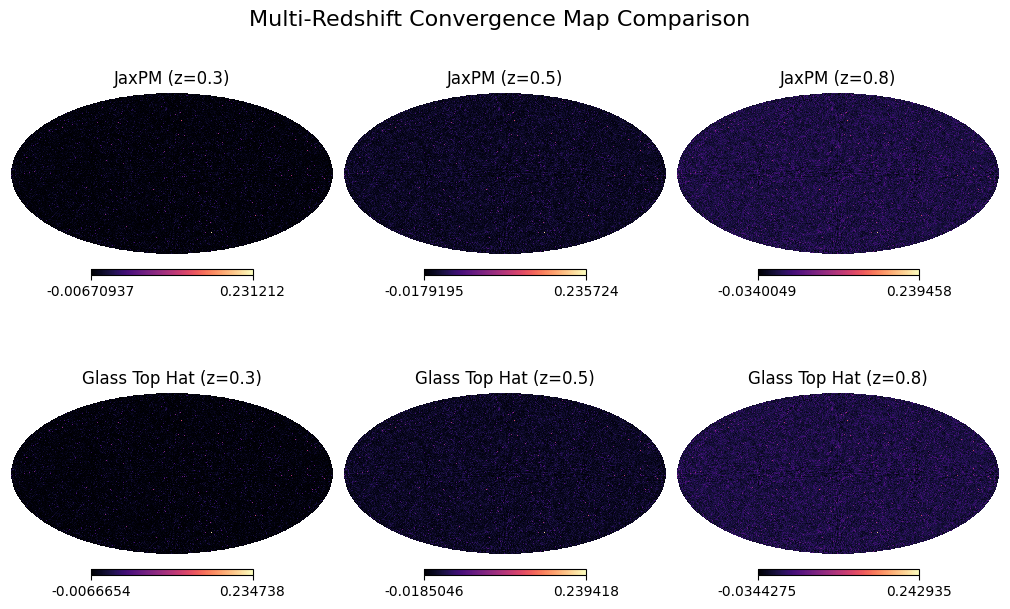

/tmp/ipykernel_157809/356423783.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


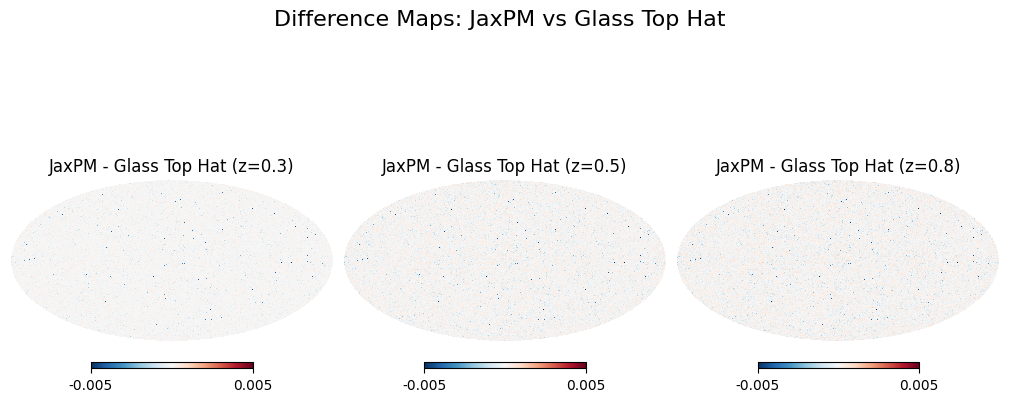


MULTI-REDSHIFT MAP-LEVEL COMPARISON STATISTICS

JaxPM vs Glass Top Hat (across all redshifts):
  z = 0.3: MSE = 5.59e-08, Corr = 0.9998, RMS ratio = 0.979, Rel RMS = 3.0%
  z = 0.5: MSE = 1.19e-07, Corr = 0.9999, RMS ratio = 0.970, Rel RMS = 3.4%
  z = 0.8: MSE = 1.41e-07, Corr = 0.9998, RMS ratio = 0.979, Rel RMS = 2.9%

Overall RMS Statistics by Method and Redshift:
------------------------------------------------------------
  z = 0.3: JaxPM = 0.007635, Glass Top Hat = 0.007800
  z = 0.5: JaxPM = 0.009929, Glass Top Hat = 0.010239
  z = 0.8: JaxPM = 0.012512, Glass Top Hat = 0.012787

✓ Multi-redshift convergence map visualization completed!


In [12]:
# Create multi-redshift convergence map visualization
factor = 1.0  # Normalization factor for convergence maps

# Apply factor to Glass top hat convergence maps
convergence_glass_top_hat_multi_factor = convergence_glass_top_hat_multi * factor

# Create comprehensive multi-redshift visualization comparing JaxPM and Glass Top Hat
fig = plt.figure(figsize=(10, 6))

# Plot convergence maps for each redshift and method
for i, z in enumerate(z_sources):
    col = i + 1
    
    # JaxPM map
    hp.mollview(convergence_jaxpm_multi[i], title=f"JaxPM (z={z})", 
                cmap="magma", sub=(2, len(z_sources), col), cbar=True, bgcolor=(0,) * 4)
    
    # Glass top hat map
    hp.mollview(convergence_glass_top_hat_multi_factor[i], title=f"Glass Top Hat (z={z})", 
                cmap="magma", sub=(2, len(z_sources), col + len(z_sources)), cbar=True, bgcolor=(0,) * 4)

plt.suptitle("Multi-Redshift Convergence Map Comparison", fontsize=16)
plt.tight_layout()
plt.show()

# Create difference maps comparing only JaxPM vs Glass Top Hat
fig = plt.figure(figsize=(10, 4))

for i, z in enumerate(z_sources):
    col = i + 1
    
    # Compute difference maps for this redshift
    diff_jaxpm_tophat = np.array(convergence_jaxpm_multi[i]) - convergence_glass_top_hat_multi_factor[i]
    
    # JaxPM - Glass Top Hat for all redshifts  
    hp.mollview(diff_jaxpm_tophat, title=f"JaxPM - Glass Top Hat (z={z})", 
                sub=(1, len(z_sources), col), cbar=True, min=-0.005, max=0.005, cmap='RdBu_r', bgcolor=(0,) * 4)

plt.suptitle("Difference Maps: JaxPM vs Glass Top Hat", fontsize=16)
plt.tight_layout()
plt.show()

# Compute comprehensive multi-redshift statistics
print("\n" + "="*80)
print("MULTI-REDSHIFT MAP-LEVEL COMPARISON STATISTICS")
print("="*80)

# JaxPM vs Glass Top Hat
stats_tophat = compute_multi_redshift_statistics(
    convergence_jaxpm_multi, convergence_glass_top_hat_multi_factor, z_sources
)

print(f"\nJaxPM vs Glass Top Hat (across all redshifts):")
for i, z in enumerate(z_sources):
    print(f"  z = {z:.1f}: MSE = {stats_tophat['mse'][i]:.2e}, "
          f"Corr = {stats_tophat['correlation'][i]:.4f}, "
          f"RMS ratio = {stats_tophat['rms_ratio'][i]:.3f}, "
          f"Rel RMS = {stats_tophat['relative_rms'][i]:.1%}")

# Overall RMS statistics for each method and redshift
print(f"\nOverall RMS Statistics by Method and Redshift:")
print("-" * 60)
for i, z in enumerate(z_sources):
    jaxpm_rms = np.sqrt(np.mean(convergence_jaxpm_multi[i]**2))
    glass_top_rms = np.sqrt(np.mean(convergence_glass_top_hat_multi_factor[i]**2))
    
    print(f"  z = {z:.1f}: JaxPM = {jaxpm_rms:.6f}, "
          f"Glass Top Hat = {glass_top_rms:.6f}")

print("\n✓ Multi-redshift convergence map visualization completed!")

# Main Result: Power Spectrum Comparison Plot

## Power Spectrum Functions

In [13]:
def compute_power_spectrum(convergence_map, low_ell_cutoff=2):
    """
    Compute angular power spectrum from HEALPix map.
    """
    nside = hp.npix2nside(len(convergence_map))
    cl_full = hp.anafast(np.array(convergence_map))
    ell_full = np.arange(len(cl_full))

    # Apply low-ell cutoff
    ell = ell_full[low_ell_cutoff:]
    cl = cl_full[low_ell_cutoff:]

    return ell, cl


def compute_theory_cl(cosmo, ell, z_source):
    """
    Compute theoretical angular power spectrum.
    """
    tracer = jc.probes.WeakLensing(
        [jc.redshift.delta_nz(z_source)],
        sigma_e=0.0,  # No shape noise
    )

    cl_theory = jc.angular_cl.angular_cl(cosmo=cosmo, ell=ell, probes=[tracer])

    return cl_theory[0]  # Return auto-correlation


def compute_mse(map1, map2):
    """
    Compute Mean Squared Error between two maps.
    """
    return np.mean((map1 - map2)**2)


def compute_correlation(map1, map2):
    """
    Compute correlation coefficient between two maps.
    """
    return np.corrcoef(map1.flatten(), map2.flatten())[0, 1]



print("✓ Analysis functions defined")

✓ Analysis functions defined


## Power Spectrum Analysis and Visualization

In [14]:
print("=" * 80)
print("POWER SPECTRUM ANALYSIS")
print("=" * 80)

# Initialize results storage for each redshift
power_spectrum_results = {}

print("Computing power spectra for each redshift individually...")

# Process each redshift using single-redshift functions
for i, z_source in enumerate(z_sources):
    print(f"\nProcessing redshift z = {z_source:.1f}")
    
    # Extract single convergence maps for this redshift
    kappa_jaxpm = convergence_jaxpm_multi[i]
    kappa_glass_top = convergence_glass_top_hat_multi_factor[i]
    
    # Compute power spectra using single-redshift functions
    print(f"  Computing JaxPM power spectrum...")
    ell_jax, cl_jax = compute_power_spectrum(kappa_jaxpm, low_ell_cutoff)
    
    print(f"  Computing Glass top-hat power spectrum...")
    ell_top, cl_top = compute_power_spectrum(kappa_glass_top, low_ell_cutoff)
    
    # Use common ell range (take minimum length)
    min_ell_len = min(len(ell_jax), len(ell_top))
    ell_common = ell_jax[:min_ell_len]
    
    # Truncate all power spectra to common range
    cl_jax = cl_jax[:min_ell_len]
    cl_top = cl_top[:min_ell_len]
    
    # Compute theory power spectrum for this redshift
    print(f"  Computing theoretical power spectrum...")
    cl_theory = compute_theory_cl(cosmo, ell_common, z_source)
    
    def safe_ratio(num, denom):
        return np.divide(num, denom, out=np.zeros_like(num), where=denom != 0)

    combo_arrays = {
        'jaxpm_glass_tophat': (cl_jax, cl_top),
        'jaxpm_theory': (cl_jax, cl_theory),
        'glass_tophat_theory': (cl_top, cl_theory)
    }

    def calc_metrics(mask):
        if mask is None:
            mask = np.ones_like(ell_common, dtype=bool)
        if not np.any(mask):
            return {'mse': {}, 'ratio_mean': {}}

        mse_values = {}
        ratio_values = {}
        for name, (arr1, arr2) in combo_arrays.items():
            diff = arr1[mask] - arr2[mask]
            mse_values[name] = float(np.mean(diff**2))
            ratio_values[name] = float(np.mean(safe_ratio(arr1[mask], arr2[mask])))
        return {'mse': mse_values, 'ratio_mean': ratio_values}

    metrics_full = calc_metrics(mask=None)
    mask_ell_10_100 = (ell_common >= 10) & (ell_common <= 100)
    metrics_mid = calc_metrics(mask_ell_10_100)
    
    # Store results for this redshift
    power_spectrum_results[z_source] = {
        'ell': ell_common,
        'cl_jaxpm': cl_jax,
        'cl_glass_tophat': cl_top,
        'cl_theory': cl_theory,
        'metrics': {
            'full': metrics_full,
            'ell_10_100': metrics_mid
        }
    }
    
    print(f"  ✓ Computed {len(ell_common)} multipoles from ell={ell_common[0]} to ell={ell_common[-1]}")

print(f"\n✓ Power spectrum analysis completed for all {len(z_sources)} redshifts!")

POWER SPECTRUM ANALYSIS
Computing power spectra for each redshift individually...

Processing redshift z = 0.3
  Computing JaxPM power spectrum...
  Computing Glass top-hat power spectrum...
  Computing theoretical power spectrum...
  ✓ Computed 766 multipoles from ell=2 to ell=767

Processing redshift z = 0.5
  Computing JaxPM power spectrum...
  Computing Glass top-hat power spectrum...
  Computing theoretical power spectrum...
  ✓ Computed 766 multipoles from ell=2 to ell=767

Processing redshift z = 0.8
  Computing JaxPM power spectrum...
  Computing Glass top-hat power spectrum...
  Computing theoretical power spectrum...
  ✓ Computed 766 multipoles from ell=2 to ell=767

✓ Power spectrum analysis completed for all 3 redshifts!


Creating 2xN power spectrum comparison plots...


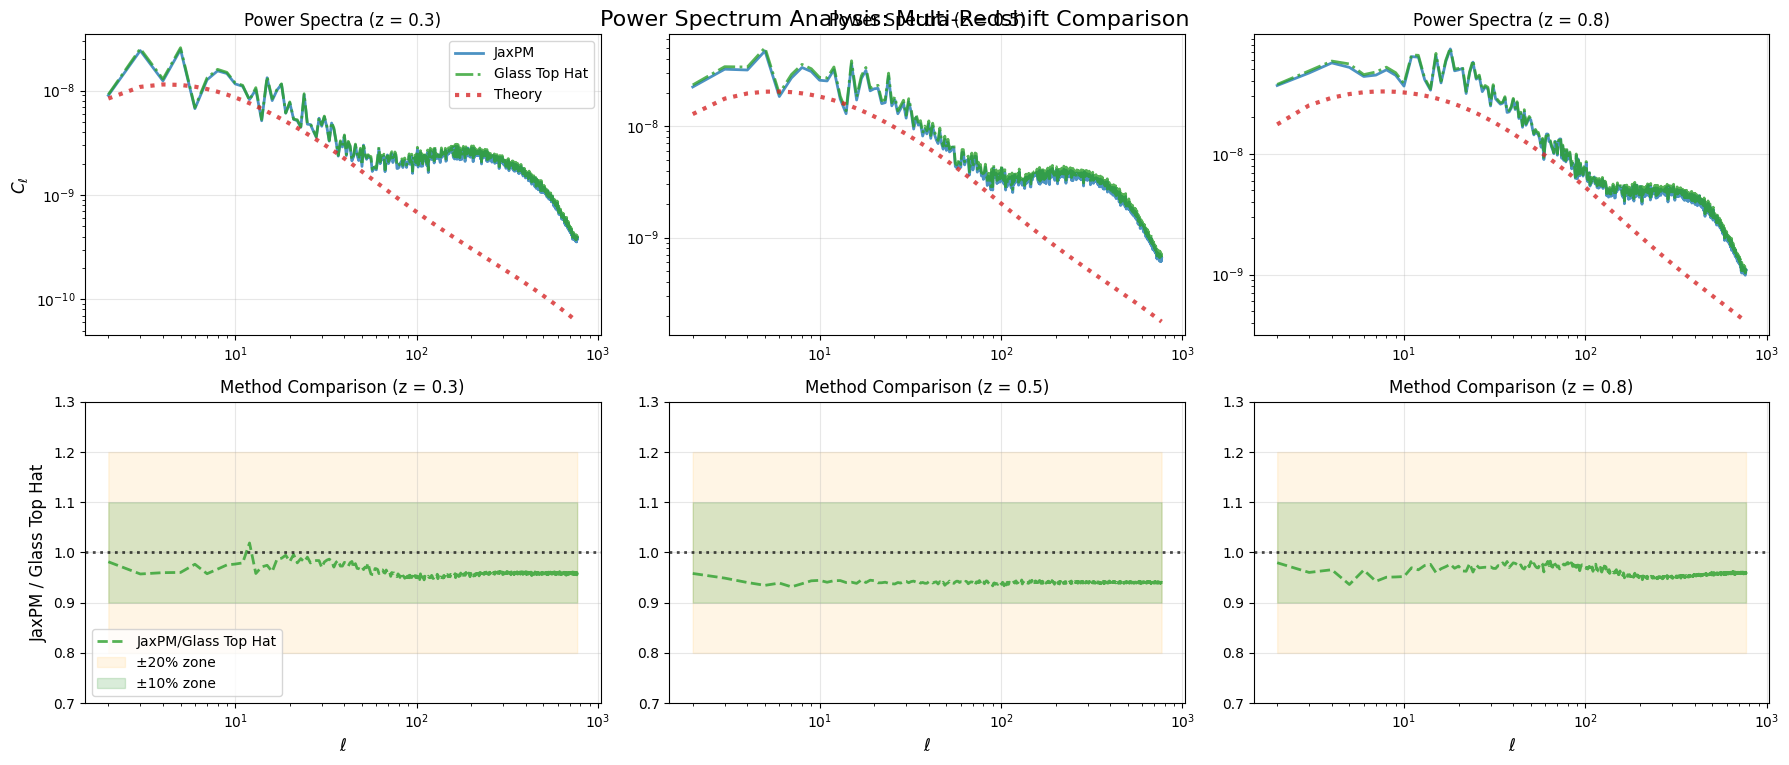


POWER SPECTRUM STATISTICS SUMMARY

Redshift z = 0.3 (ell ∈ [10, 100]):
----------------------------------------
  Theory Agreement:
    JaxPM/Theory:     1.822
    Glass Top/Theory: 1.890
  Method Agreement:
    JaxPM/Glass Top:  0.967
  Cℓ MSE & ratios (all ℓ):
    MSE[JaxPM, Glass Top] = 1.079e-20, ratio = 0.959
  Cℓ MSE & ratios (ℓ ∈ [10, 100]):
    MSE[JaxPM, Glass Top] = 1.461e-20, ratio = 0.967

Redshift z = 0.5 (ell ∈ [10, 100]):
----------------------------------------
  Theory Agreement:
    JaxPM/Theory:     1.473
    Glass Top/Theory: 1.567
  Method Agreement:
    JaxPM/Glass Top:  0.940
  Cℓ MSE & ratios (all ℓ):
    MSE[JaxPM, Glass Top] = 1.322e-19, ratio = 0.940
  Cℓ MSE & ratios (ℓ ∈ [10, 100]):
    MSE[JaxPM, Glass Top] = 5.576e-19, ratio = 0.940

Redshift z = 0.8 (ell ∈ [10, 100]):
----------------------------------------
  Theory Agreement:
    JaxPM/Theory:     1.511
    Glass Top/Theory: 1.554
  Method Agreement:
    JaxPM/Glass Top:  0.973
  Cℓ MSE & ratios (all 

In [15]:
# Create 2xN power spectrum comparison plots for multiple redshifts
print("Creating 2xN power spectrum comparison plots...")

fig, axes_raw = plt.subplots(2, len(z_sources), figsize=(18, 8))

# Handle single vs multiple redshifts - ensure axes is always 2D
if len(z_sources) == 1:
    axes = axes_raw.reshape(-1, 1)  # Convert 1D to 2D for single redshift
else:
    axes = axes_raw

# Define colors for different methods
colors = {
    'jaxpm': '#1f77b4',
    'glass_top': '#2ca02c',
    'theory': '#d62728'
}

# Process each redshift (column)
for col, z_source in enumerate(z_sources):
    results = power_spectrum_results[z_source]
    ell = results['ell']
    cl_jaxpm = results['cl_jaxpm']
    cl_glass_top = results['cl_glass_tophat']
    cl_theory = results['cl_theory']
    
    # Row 1: Power spectra comparison
    ax1 = axes[0, col]
    ax1.loglog(ell, cl_jaxpm, '-', color=colors['jaxpm'], linewidth=2, alpha=0.8, label='JaxPM')
    ax1.loglog(ell, cl_glass_top, '-.', color=colors['glass_top'], linewidth=2, alpha=0.8, label='Glass Top Hat')
    ax1.loglog(ell, cl_theory, ':', color=colors['theory'], linewidth=3, alpha=0.8, label='Theory')
    
    ax1.set_title(f'Power Spectra (z = {z_source:.1f})', fontsize=12)
    if col == 0:
        ax1.set_ylabel(r'$C_\ell$', fontsize=12)
        ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Row 2: Method comparisons (JaxPM/Glass Top Hat ratios only)
    ax2 = axes[1, col]
    ratio_jax_top = cl_jaxpm / cl_glass_top
    
    ax2.semilogx(ell, ratio_jax_top, '--', color=colors['glass_top'], linewidth=2, alpha=0.8, label='JaxPM/Glass Top Hat')
    ax2.axhline(1, color='black', linestyle=':', alpha=0.7, linewidth=2)
    
    # Add agreement zones with labels
    ax2.fill_between(ell, 0.8, 1.2, alpha=0.1, color='orange', label='±20% zone' if col == 0 else '')
    ax2.fill_between(ell, 0.9, 1.1, alpha=0.15, color='green', label='±10% zone' if col == 0 else '')
    
    ax2.set_title(f'Method Comparison (z = {z_source:.1f})', fontsize=12)
    ax2.set_xlabel(r'$\ell$', fontsize=12)
    if col == 0:
        ax2.set_ylabel('JaxPM / Glass Top Hat', fontsize=12)
        ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0.7, 1.3)

plt.suptitle('Power Spectrum Analysis: Multi-Redshift Comparison', fontsize=16, y=0.95)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("POWER SPECTRUM STATISTICS SUMMARY")
print("="*80)

for z_source in z_sources:
    results = power_spectrum_results[z_source]
    ell = results['ell'] 
    cl_jaxpm = results['cl_jaxpm']
    cl_glass_top = results['cl_glass_tophat']
    cl_theory = results['cl_theory']
    metrics_full = results['metrics']['full']
    metrics_mid = results['metrics']['ell_10_100']
    
    # Focus on well-resolved scales
    mask = (ell >= 10) & (ell <= 100)
    
    print(f"\nRedshift z = {z_source:.1f} (ell ∈ [10, 100]):")
    print("-" * 40)
    
    # Theory agreement
    ratio_jax_theory = np.mean((cl_jaxpm / cl_theory)[mask])
    ratio_top_theory = np.mean((cl_glass_top / cl_theory)[mask])
    
    print(f"  Theory Agreement:")
    print(f"    JaxPM/Theory:     {ratio_jax_theory:.3f}")
    print(f"    Glass Top/Theory: {ratio_top_theory:.3f}")
    
    # Method agreement
    ratio_jax_top = np.mean((cl_jaxpm / cl_glass_top)[mask])
    
    print(f"  Method Agreement:")
    print(f"    JaxPM/Glass Top:  {ratio_jax_top:.3f}")

    def _get_metric(metric_block, kind, name):
        if not metric_block or kind not in metric_block or name not in metric_block[kind]:
            return np.nan
        return metric_block[kind][name]

    print(f"  Cℓ MSE & ratios (all ℓ):")
    print(
        f"    MSE[JaxPM, Glass Top] = {_get_metric(metrics_full, 'mse', 'jaxpm_glass_tophat'):.3e}, "
        f"ratio = {_get_metric(metrics_full, 'ratio_mean', 'jaxpm_glass_tophat'):.3f}"
    )

    print(f"  Cℓ MSE & ratios (ℓ ∈ [10, 100]):")
    print(
        f"    MSE[JaxPM, Glass Top] = {_get_metric(metrics_mid, 'mse', 'jaxpm_glass_tophat'):.3e}, "
        f"ratio = {_get_metric(metrics_mid, 'ratio_mean', 'jaxpm_glass_tophat'):.3f}"
    )

print("\n✓ Power spectrum analysis and visualization completed!")